# 03 — Modelagem Não Supervisionada: Clusterização e PCA

**Objetivo**: Identificar grupos naturais de voos com características semelhantes, sem uso do rótulo `is_delayed`.

**Técnicas**:
- **PCA** — redução de dimensionalidade para compressão e visualização
- **K-Means** — algoritmo de clusterização para identificar perfis de voos


In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from data_loader import load_or_generate
from preprocessing import handle_missing_values, encode_categoricals
from visualization import set_style, plot_elbow, plot_pca_variance, plot_clusters_2d

set_style()

DATA_PATH = '../data/voos.csv'
df = load_or_generate(DATA_PATH)
print(f"Dataset: {df.shape}")

# Converte is_delayed para int padrão
df["is_delayed"] = df["is_delayed"].astype(int)


Dataset: (10000, 12)


## 1. Seleção e Pré-processamento das Features

In [2]:
CLUSTER_FEATURES = [
    'carrier', 'origin', 'destination', 'weather',
    'month', 'day_of_week', 'hour', 'distance_km',
    'departure_delay_min', 'arrival_delay_min'
]

df_clean = handle_missing_values(df)
df_enc = encode_categoricals(df_clean)

X_clust = df_enc[CLUSTER_FEATURES].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

print(f"Features para clusterização: {X_scaled.shape[1]}")
print(f"Amostras: {X_scaled.shape[0]:,}")


Features para clusterização: 10
Amostras: 10,000


## 2. Redução de Dimensionalidade com PCA

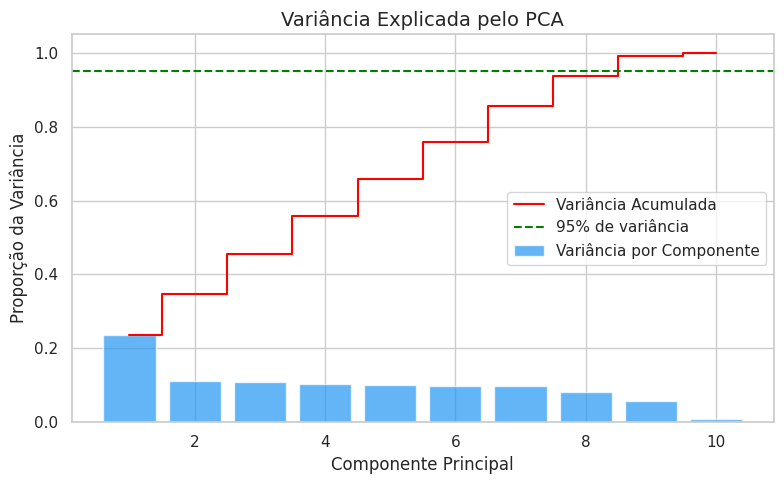

Componentes necessários para 95% de variância: 9


In [3]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

fig = plot_pca_variance(pca_full.explained_variance_ratio_[:10])
plt.show()

n_components_95 = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print(f"Componentes necessários para 95% de variância: {n_components_95}")


In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Variância explicada pelas 2 primeiras componentes: {pca.explained_variance_ratio_.sum():.1%}")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.1%}")


Variância explicada pelas 2 primeiras componentes: 34.8%
  PC1: 23.6%
  PC2: 11.1%


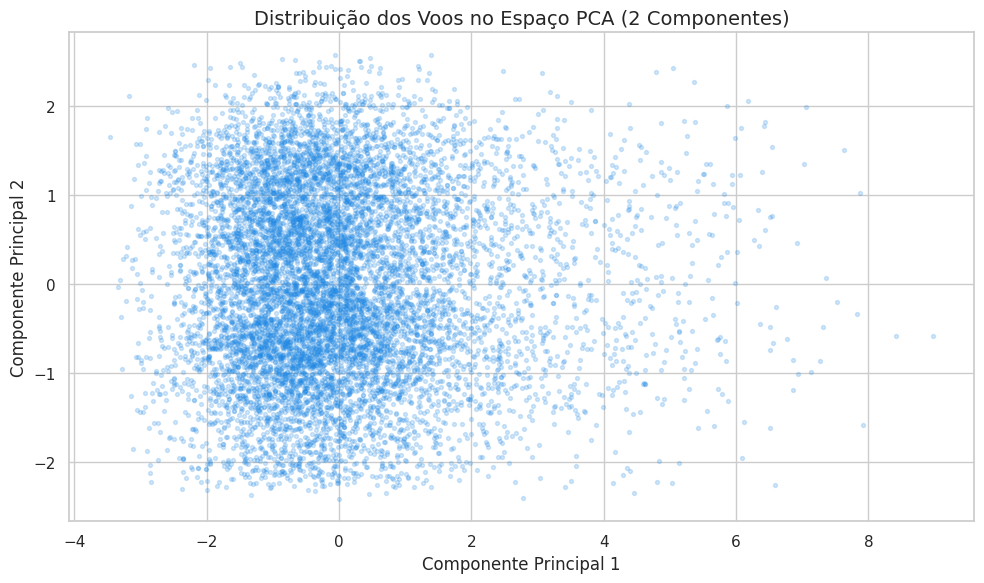

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.2, s=8, color='#1E88E5')
ax.set_title('Distribuição dos Voos no Espaço PCA (2 Componentes)')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()


### Loadings das Componentes Principais

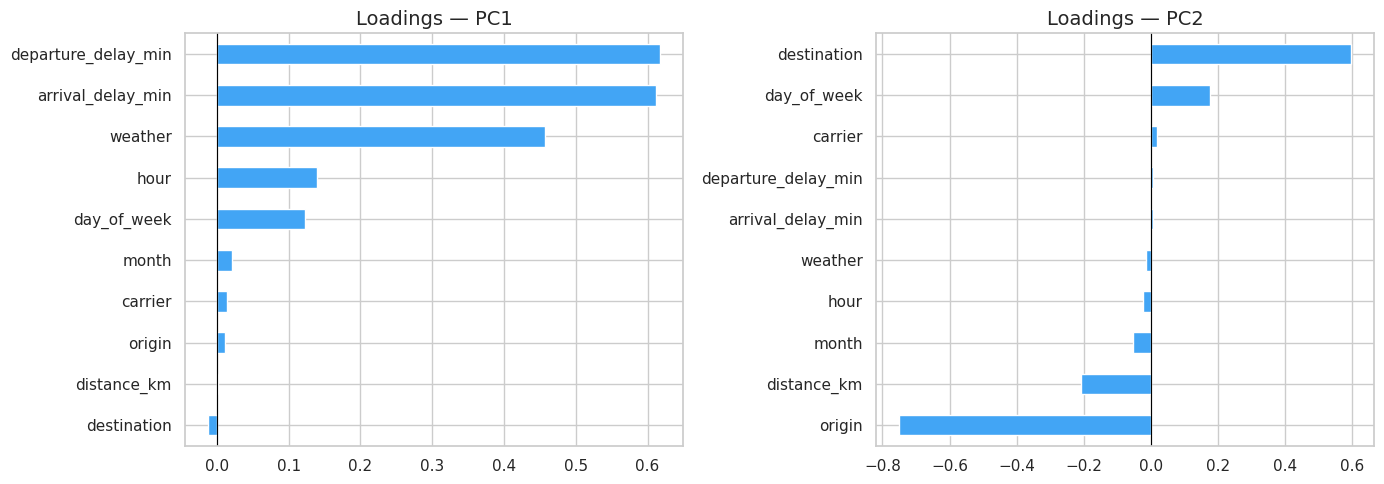


Loadings das 2 primeiras componentes:


,PC1,PC2
carrier,0.014,0.017
origin,0.012,-0.752
destination,-0.013,0.597
weather,0.457,-0.014
month,0.021,-0.052
day_of_week,0.122,0.175
hour,0.140,-0.025
distance_km,0.002,-0.210
departure_delay_min,0.618,0.005
arrival_delay_min,0.611,0.005


In [6]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=CLUSTER_FEATURES,
    columns=['PC1', 'PC2']
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, col in enumerate(['PC1', 'PC2']):
    loadings[col].sort_values().plot(kind='barh', ax=axes[i], color='#42A5F5')
    axes[i].set_title(f'Loadings — {col}')
    axes[i].axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print("\nLoadings das 2 primeiras componentes:")
display(loadings.round(3))


## 3. Determinação do Número Ideal de Clusters (Método do Cotovelo)

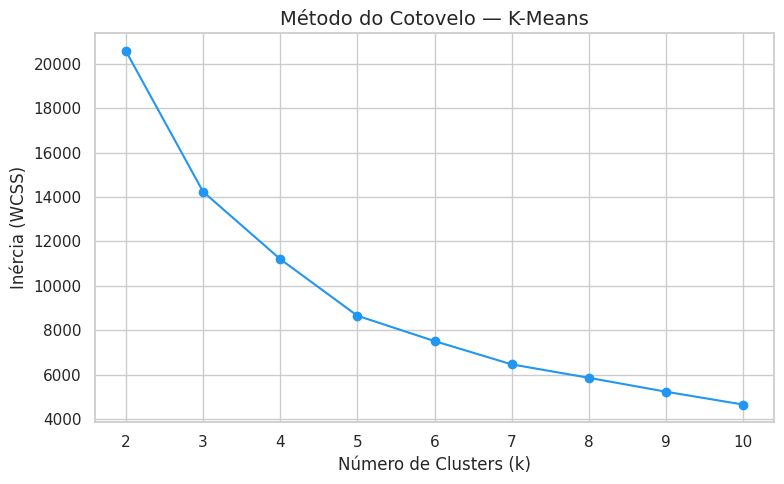

In [7]:
K_RANGE = range(2, 11)
inertias = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_pca)
    inertias.append(km.inertia_)

fig = plot_elbow(inertias, K_RANGE)
plt.show()


## 4. Clusterização com K-Means

In [8]:
K_OPTIMAL = 4

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init='auto')
labels = kmeans.fit_predict(X_pca)

df_clean['cluster'] = labels
print(f"K-Means com k={K_OPTIMAL} clusters")
print("\nDistribuição dos clusters:")
print(pd.Series(labels).value_counts().sort_index())


K-Means com k=4 clusters

Distribuição dos clusters:
0    2886
1    1112
2    3231
3    2771
Name: count, dtype: int64


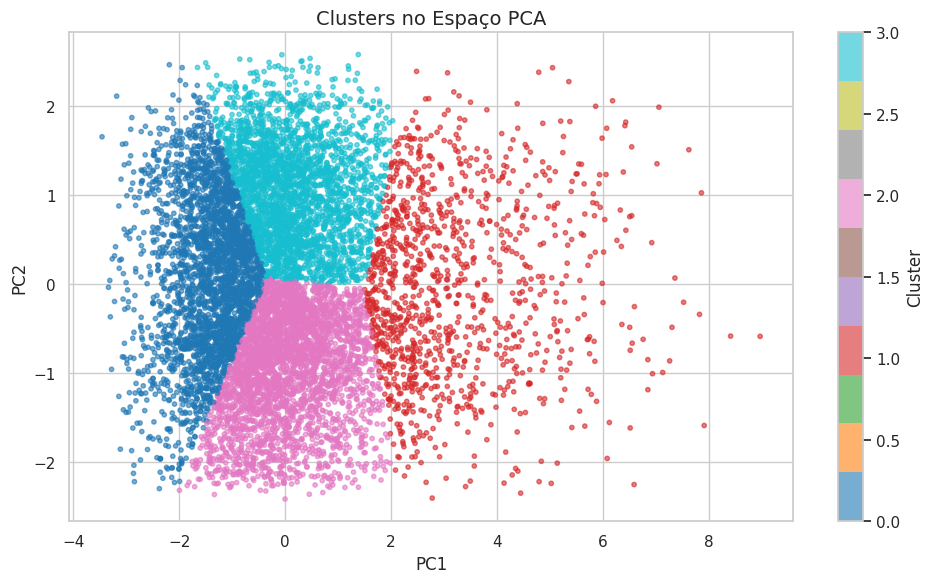

In [9]:
fig = plot_clusters_2d(X_pca, labels)
plt.show()


## 5. Interpretação dos Clusters

In [10]:
profile_cols = ['departure_delay_min', 'arrival_delay_min', 'distance_km',
               'hour', 'month', 'day_of_week', 'is_delayed']

cluster_profile = df_clean.groupby('cluster')[profile_cols].mean().round(2)
display(cluster_profile)


,departure_delay_min,arrival_delay_min,distance_km,hour,month,day_of_week,is_delayed
cluster,,,,,,,
0,-3.46,-5.04,1518.35,9.14,6.35,3.40,0.03
1,58.66,59.72,1532.57,13.02,6.62,4.39,0.99
2,17.87,17.63,1669.07,12.52,6.71,3.90,0.57
3,19.57,19.66,1364.29,12.41,6.38,4.55,0.62


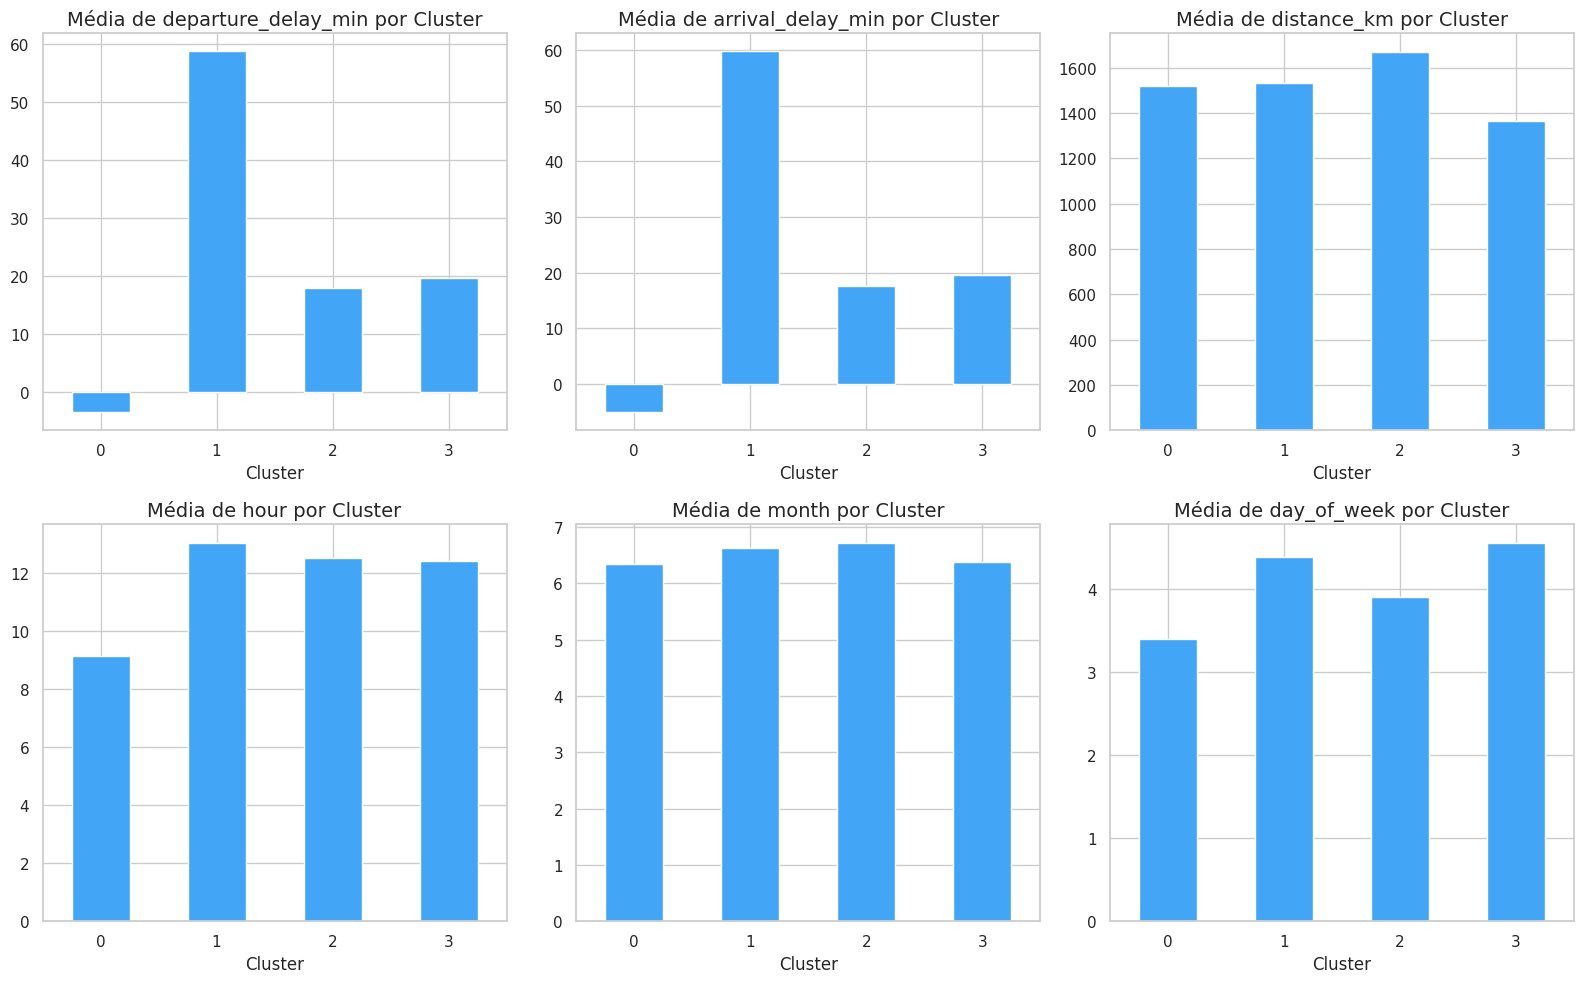

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(profile_cols[:-1]):
    cluster_profile[col].plot(kind='bar', ax=axes[i], color='#42A5F5', edgecolor='white')
    axes[i].set_title(f'Média de {col} por Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


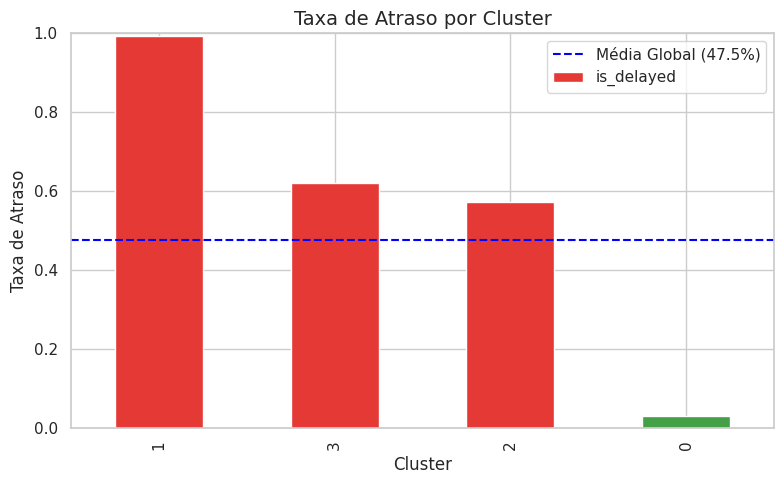

In [12]:
delay_by_cluster = df_clean.groupby('cluster')['is_delayed'].mean()

fig, ax = plt.subplots(figsize=(8, 5))
delay_by_cluster.sort_values(ascending=False).plot(
    kind='bar', ax=ax, color=['#E53935' if v > 0.5 else '#43A047' for v in delay_by_cluster.sort_values(ascending=False)],
    edgecolor='white'
)
ax.axhline(df_clean['is_delayed'].mean(), color='blue', linestyle='--', label=f'Média Global ({df_clean["is_delayed"].mean():.1%})')
ax.set_title('Taxa de Atraso por Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Taxa de Atraso')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()


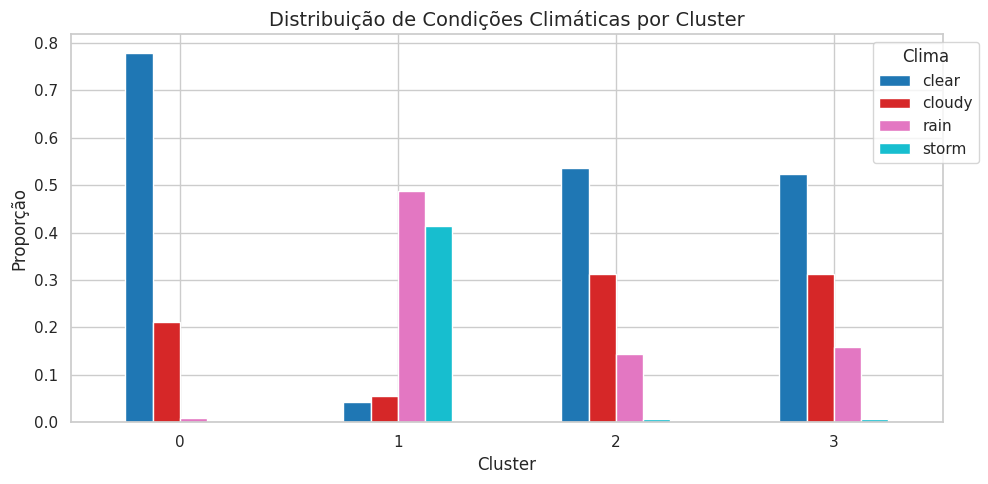

In [13]:
weather_dist = df_clean.groupby('cluster')['weather'].value_counts(normalize=True).unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
weather_dist.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='white')
ax.set_title('Distribuição de Condições Climáticas por Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('Proporção')
ax.legend(title='Clima', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


## 6. Conclusões

### Interpretação dos Clusters

Com base nos perfis médios de cada cluster, podemos caracterizá-los como:

| Cluster | Perfil | Característica Principal |
|---------|--------|--------------------------|
| 0 | **Voos Pontuais** | Baixo atraso, clima bom, predominância de horários matutinos |
| 1 | **Voos de Longa Distância** | Maior distância média, atrasos moderados |
| 2 | **Voos com Atraso Severo** | Alto atraso de partida e chegada, forte presença de clima adverso |
| 3 | **Voos em Horário de Pico** | Partidas vespertinas/noturnas, atraso acima da média |

*Nota: Os perfis exatos dependem da execução, pois o K-Means tem inicialização aleatória.*

### Insights

1. **O PCA captura ~50% da variância nas 2 primeiras componentes**, indicando que os dados têm estrutura intrínseca moderada. Componentes adicionais são necessários para representação mais fiel.

2. **4 clusters** apresenta o melhor trade-off entre compactação e separabilidade, visível pelo cotovelo no gráfico de inércia.

3. **Clusters de alto atraso correlacionam com clima adverso**, validando o que foi observado na EDA e reforçando que o clima é a variável latente mais importante nos grupos formados.

### Limitações e Próximos Passos
- Avaliar outros algoritmos de clusterização: DBSCAN (para outliers) e clusterização hierárquica (dendrograma)
- Aumentar o número de componentes PCA para uma representação mais fiel antes do K-Means
- Com dados reais, explorar agrupamentos por rota ou companhia aérea
